# Fashion-MNIST 卷积神经网络完整案例

这个 Notebook 使用 **卷积神经网络** 识别 Fashion-MNIST 服饰图片。

Fashion-MNIST 中每张图片都是 28×28 的灰度图，类别包括 T 恤、裤子、鞋子、包等。前面使用全连接神经网络时，通常会先把图片 `Flatten` 成 784 个数字。卷积神经网络的关键区别是：

```text
先保留图片的二维结构
再用卷积核扫描局部区域
逐步提取边缘、纹理、轮廓等局部特征
```

本案例会依次完成：

1. 加载 Fashion-MNIST 数据集
2. 观察图片和标签
3. 理解 CNN 输入形状
4. 数据归一化和通道维度处理
5. 构建 CNN 模型
6. 训练模型
7. 可视化卷积特征图和池化特征图
8. 绘制训练曲线
9. 测试集评估
10. 单张预测和批量预测
11. 混淆矩阵和错误案例分析
12. 保存并重新加载模型

---

## CNN 的核心直觉

全连接网络把图片看成一排数字。  
卷积神经网络把图片看成有空间结构的网格。

```text
全连接网络：先 Flatten，再分类
CNN：先提取局部图像特征，再分类
```

这就是 CNN 特别适合图像任务的重要原因。

# 第 0 步：环境准备

如果还没有安装相关库，可以先在终端中运行：

```bash
python -m pip install tensorflow matplotlib numpy
```

如果在 Notebook 中运行，也可以新建一个代码单元格执行：

```python
!python -m pip install tensorflow matplotlib numpy
```

本案例主要使用：

- `tensorflow`：构建和训练神经网络
- `keras`：TensorFlow 中的高级神经网络接口
- `numpy`：处理数组和数值计算
- `matplotlib`：展示图片和绘制图表

In [1]:
# ============================================================
# 第 0 步：环境准备与库导入
# ============================================================

import os

# ------------------------------------------------------------
# 必须在导入 tensorflow / keras 之前设置。
# 如果本机 Keras 默认后端不是 TensorFlow，这一行可以确保本案例使用 TensorFlow。
# ------------------------------------------------------------
os.environ["KERAS_BACKEND"] = "tensorflow"

# 减少不影响学习的 TensorFlow 提示信息。
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "1"

import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow 版本：", tf.__version__)
print("Keras 版本：", keras.__version__)
print("当前 Keras 后端：tensorflow")

TensorFlow 版本： 2.21.0
Keras 版本： 3.14.1
当前 Keras 后端：tensorflow


# 第 0.1 步：设置中文字体

如果图表中的中文显示为方框，通常是因为 Matplotlib 没有找到中文字体。

下面会按顺序尝试常见中文字体：

- macOS：`PingFang SC`、`Heiti SC`、`Arial Unicode MS`
- Windows：`Microsoft YaHei`、`SimHei`
- Linux：`Noto Sans CJK SC`、`WenQuanYi Zen Hei`

In [2]:
# ============================================================
# 第 0.1 步：设置 Matplotlib 中文字体
# ============================================================

def set_chinese_font():
    """
    设置 Matplotlib 中文字体。

    说明：
    1. Matplotlib 会按顺序寻找字体。
    2. 找到第一个系统中存在的字体后，就会使用它。
    3. 如果所有字体都不存在，中文可能仍然显示为方框。
    """
    plt.rcParams["font.sans-serif"] = [
        "PingFang SC",
        "Heiti SC",
        "Arial Unicode MS",
        "Microsoft YaHei",
        "SimHei",
        "Noto Sans CJK SC",
        "WenQuanYi Zen Hei",
        "DejaVu Sans",
    ]
    plt.rcParams["axes.unicode_minus"] = False

set_chinese_font()
print("中文字体设置完成。")

中文字体设置完成。


# 第 0.2 步：固定随机种子

神经网络训练中有很多随机因素，例如：

- 参数初始化
- 数据打乱
- Dropout 随机丢弃神经元
- 随机抽取图片展示

固定随机种子后，每次运行结果会尽量接近，方便对照观察。

In [3]:
# ============================================================
# 第 0.2 步：固定随机种子
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("随机种子已固定：", SEED)

随机种子已固定： 42


# 第 1 步：加载 Fashion-MNIST 数据集

Fashion-MNIST 是一个服饰图像分类数据集。

它包含：

- 60,000 张训练图片
- 10,000 张测试图片
- 每张图片大小为 28×28
- 每张图片是灰度图
- 每张图片属于 10 个类别之一

| 标签编号 | 英文类别 | 中文含义 |
|---|---|---|
| 0 | T-shirt/top | T恤 / 上衣 |
| 1 | Trouser | 裤子 |
| 2 | Pullover | 套头衫 |
| 3 | Dress | 连衣裙 |
| 4 | Coat | 外套 |
| 5 | Sandal | 凉鞋 |
| 6 | Shirt | 衬衫 |
| 7 | Sneaker | 运动鞋 |
| 8 | Bag | 包 |
| 9 | Ankle boot | 短靴 |

In [4]:
# ============================================================
# 第 1 步：加载 Fashion-MNIST 数据集
# ============================================================

(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names_en = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

class_names_cn = [
    "T恤/上衣", "裤子", "套头衫", "连衣裙", "外套",
    "凉鞋", "衬衫", "运动鞋", "包", "短靴",
]

print("训练图片形状：", x_train_full.shape)
print("训练标签形状：", y_train_full.shape)
print("测试图片形状：", x_test.shape)
print("测试标签形状：", y_test.shape)
print("单张图片形状：", x_train_full[0].shape)
print("第一张图片标签：", y_train_full[0], class_names_cn[y_train_full[0]])

训练图片形状： (60000, 28, 28)
训练标签形状： (60000,)
测试图片形状： (10000, 28, 28)
测试标签形状： (10000,)
单张图片形状： (28, 28)
第一张图片标签： 9 短靴


# 第 2 步：观察一批原始图片

训练模型之前，先观察数据本身。

这一步可以帮助理解：

- 图片是灰度图，不是彩色图
- 每张图片只有一个类别标签
- 服饰类别之间有些很相似，例如 T 恤和衬衫、套头衫和外套

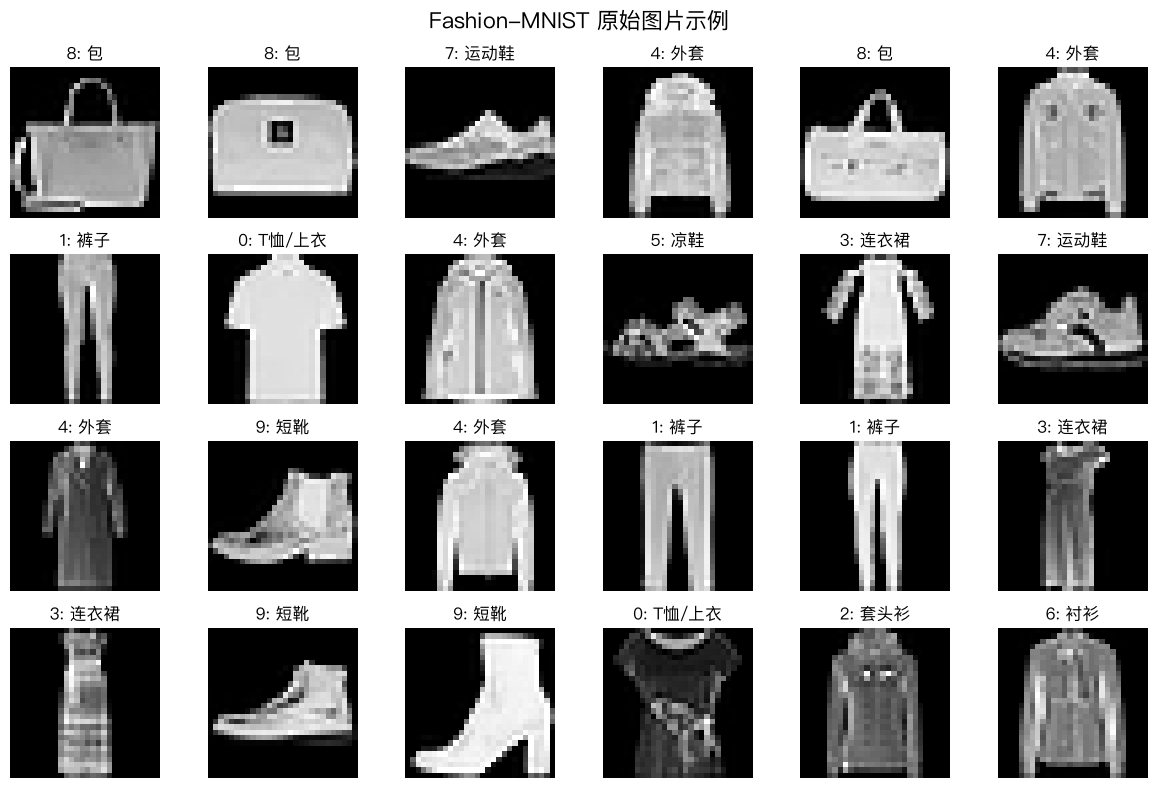

In [5]:
# ============================================================
# 第 2 步：展示一批 Fashion-MNIST 原始图片
# ============================================================

sample_indices = np.random.choice(len(x_train_full), size=24, replace=False)

plt.figure(figsize=(12, 8))
for plot_position, image_index in enumerate(sample_indices, start=1):
    image = x_train_full[image_index]
    label = y_train_full[image_index]

    plt.subplot(4, 6, plot_position)
    plt.imshow(image, cmap="gray")
    plt.title(f"{label}: {class_names_cn[label]}")
    plt.axis("off")

plt.suptitle("Fashion-MNIST 原始图片示例", fontsize=16)
plt.tight_layout()
plt.show()

# 第 3 步：观察标签分布

分类任务最好先看每个类别的数据数量。

如果某些类别特别多，某些类别特别少，模型可能偏向数量更多的类别。Fashion-MNIST 的类别分布通常比较均衡。

标签 0（T恤/上衣）：6000 张
标签 1（裤子）：6000 张
标签 2（套头衫）：6000 张
标签 3（连衣裙）：6000 张
标签 4（外套）：6000 张
标签 5（凉鞋）：6000 张
标签 6（衬衫）：6000 张
标签 7（运动鞋）：6000 张
标签 8（包）：6000 张
标签 9（短靴）：6000 张


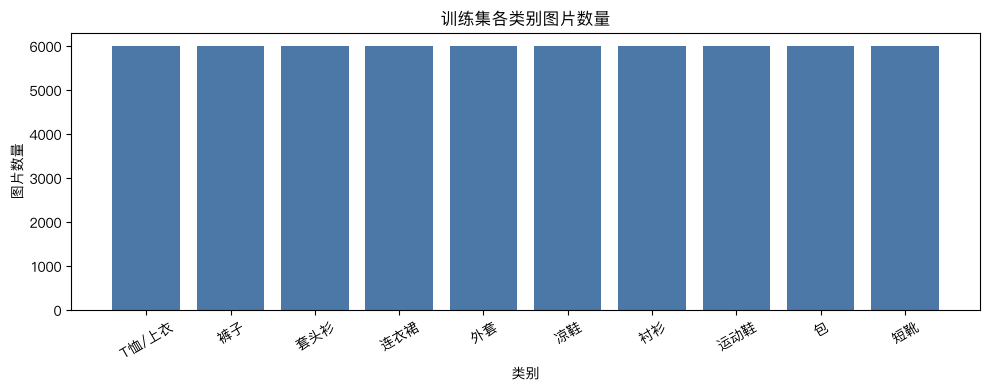

In [6]:
# ============================================================
# 第 3 步：观察训练集标签分布
# ============================================================

label_counts = np.bincount(y_train_full, minlength=10)

for label_id, count in enumerate(label_counts):
    print(f"标签 {label_id}（{class_names_cn[label_id]}）：{count} 张")

plt.figure(figsize=(10, 4))
plt.bar(class_names_cn, label_counts, color="#4C78A8")
plt.title("训练集各类别图片数量")
plt.xlabel("类别")
plt.ylabel("图片数量")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# 第 4 步：理解 CNN 输入形状

全连接网络常见输入方式：

```text
28×28 → Flatten → 784
```

CNN 的输入方式不同。CNN 希望知道图片的高度、宽度和通道数。

Fashion-MNIST 是灰度图，只有 1 个颜色通道，所以 CNN 输入形状应该是：

```text
28 × 28 × 1
```

含义是：

```text
高度 28，宽度 28，通道数 1
```

原始单张图片形状： (28, 28)
标签编号： 9
中文类别： 短靴
增加通道维度后的形状： (28, 28, 1)


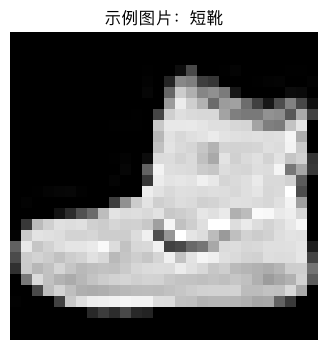

In [7]:
# ============================================================
# 第 4 步：观察图片形状，并增加通道维度
# ============================================================

example_index = 0
example_image = x_train_full[example_index]
example_label = y_train_full[example_index]

print("原始单张图片形状：", example_image.shape)
print("标签编号：", example_label)
print("中文类别：", class_names_cn[example_label])

# CNN 需要通道维度。
# 灰度图只有 1 个通道，所以把 (28, 28) 变成 (28, 28, 1)。
example_image_with_channel = np.expand_dims(example_image, axis=-1)
print("增加通道维度后的形状：", example_image_with_channel.shape)

plt.figure(figsize=(4, 4))
plt.imshow(example_image, cmap="gray")
plt.title(f"示例图片：{class_names_cn[example_label]}")
plt.axis("off")
plt.show()

# 第 5 步：数据归一化和通道维度处理

原始像素值范围是：

```text
0 到 255
```

神经网络更适合处理较小、稳定的数值范围。这里把像素值除以 255，转换到：

```text
0 到 1
```

同时，为了符合 CNN 输入格式，需要把图片形状从：

```text
(样本数, 28, 28)
```

变成：

```text
(样本数, 28, 28, 1)
```

In [8]:
# ============================================================
# 第 5 步：归一化，并增加通道维度
# ============================================================

x_train_full_normalized = x_train_full.astype("float32") / 255.0
x_test_normalized = x_test.astype("float32") / 255.0

# np.expand_dims(..., axis=-1) 会在最后增加一个维度。
x_train_full_cnn = np.expand_dims(x_train_full_normalized, axis=-1)
x_test_cnn = np.expand_dims(x_test_normalized, axis=-1)

print("归一化前像素范围：", x_train_full.min(), "到", x_train_full.max())
print("归一化后像素范围：", x_train_full_normalized.min(), "到", x_train_full_normalized.max())
print("CNN 训练图片形状：", x_train_full_cnn.shape)
print("CNN 测试图片形状：", x_test_cnn.shape)

归一化前像素范围： 0 到 255
归一化后像素范围： 0.0 到 1.0
CNN 训练图片形状： (60000, 28, 28, 1)
CNN 测试图片形状： (10000, 28, 28, 1)


# 第 6 步：拆分训练集和验证集

原始数据已经分成训练集和测试集。为了在训练过程中观察模型对新数据的表现，再从训练集中分出一部分作为验证集。

最终有三部分：

| 数据集 | 作用 |
|---|---|
| 训练集 | 用来调整模型参数 |
| 验证集 | 训练过程中观察模型表现 |
| 测试集 | 训练结束后进行最终评估 |

In [9]:
# ============================================================
# 第 6 步：拆分训练集和验证集
# ============================================================

indices = np.random.permutation(len(x_train_full_cnn))
validation_size = 10000
validation_indices = indices[:validation_size]
train_indices = indices[validation_size:]

x_train = x_train_full_cnn[train_indices]
y_train = y_train_full[train_indices]
x_val = x_train_full_cnn[validation_indices]
y_val = y_train_full[validation_indices]

print("训练集图片形状：", x_train.shape)
print("训练集标签形状：", y_train.shape)
print("验证集图片形状：", x_val.shape)
print("验证集标签形状：", y_val.shape)
print("测试集图片形状：", x_test_cnn.shape)
print("测试集标签形状：", y_test.shape)

训练集图片形状： (50000, 28, 28, 1)
训练集标签形状： (50000,)
验证集图片形状： (10000, 28, 28, 1)
验证集标签形状： (10000,)
测试集图片形状： (10000, 28, 28, 1)
测试集标签形状： (10000,)


# 第 7 步：理解卷积层和池化层

CNN 中最重要的两个结构是：

## 1. Conv2D 卷积层

卷积层会使用多个小窗口，也就是卷积核，在图片上滑动。

卷积核可以学习寻找局部特征，例如：

- 横向边缘
- 纵向边缘
- 斜线
- 纹理
- 局部轮廓

## 2. MaxPooling2D 池化层

池化层会缩小特征图尺寸，保留局部区域中最明显的特征。

例如 `MaxPooling2D(pool_size=(2, 2))` 会把宽高大致缩小一半。

```text
28×28 → 14×14
```

这样可以减少计算量，也能让模型更关注重要特征。

In [10]:
# ============================================================
# 第 7 步：构建 CNN 模型
# ============================================================

model = keras.Sequential([
    # 输入层：28×28 灰度图，1 个通道。
    layers.Input(shape=(28, 28, 1), name="input_28x28_gray_image"),

    # 第一组卷积和池化：
    # 32 个卷积核，每个卷积核大小为 3×3。
    layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same", name="conv_1_32_filters"),
    layers.MaxPooling2D(pool_size=(2, 2), name="pool_1_2x2"),

    # 第二组卷积和池化：
    # 64 个卷积核，可以学习更多、更复杂的局部特征。
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same", name="conv_2_64_filters"),
    layers.MaxPooling2D(pool_size=(2, 2), name="pool_2_2x2"),

    # Flatten：
    # 把卷积和池化得到的多张特征图拉平成一维向量。
    layers.Flatten(name="flatten_feature_maps"),

    # 全连接层：
    # 根据提取到的图像特征进行分类判断。
    layers.Dense(128, activation="relu", name="dense_128_relu"),

    # Dropout：
    # 随机丢弃一部分神经元，减少过拟合。
    layers.Dropout(0.30, name="dropout_30_percent"),

    # 输出层：
    # 10 个神经元对应 10 个服饰类别。
    layers.Dense(10, activation="softmax", name="output_10_softmax"),
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1_32_filters (Conv2D)      │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1_2x2 (MaxPooling2D)       │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2_64_filters (Conv2D)      │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2_2x2 (MaxPooling2D)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_feature_maps (Flatten)  │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128_relu (Dense)          │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30_percent (Dropout)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_10_softmax (Dense)       │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

# 第 8 步：观察 CNN 中数据形状的变化

从 `model.summary()` 可以看到每一层输出形状。

大致变化如下：

```text
输入图片：28×28×1
卷积后：28×28×32
池化后：14×14×32
卷积后：14×14×64
池化后：7×7×64
Flatten 后：3136
Dense 后：128
输出：10
```

这说明 CNN 不是一开始就把图片压成 784 个数字，而是先提取空间特征，再进入全连接分类层。

In [11]:
# ============================================================
# 第 8 步：手动观察关键形状
# ============================================================

print("输入形状：", (28, 28, 1))
print("第一次池化后大约形状：", (14, 14, 32))
print("第二次池化后大约形状：", (7, 7, 64))
print("Flatten 后特征数量：", 7 * 7 * 64)
print("模型总参数数量：", model.count_params())

输入形状： (28, 28, 1)
第一次池化后大约形状： (14, 14, 32)
第二次池化后大约形状： (7, 7, 64)
Flatten 后特征数量： 3136
模型总参数数量： 421642


# 第 9 步：训练 CNN 模型

训练时，每一轮 `epoch` 会完整看一遍训练集。

本案例默认训练 12 轮。Fashion-MNIST 数据集不算很大，CNN 通常可以达到较好的准确率。

In [12]:
# ============================================================
# 第 9 步：训练 CNN 模型
# ============================================================

EPOCHS = 12
BATCH_SIZE = 128

history = model.fit(
    x_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val),
    verbose=2,
)

Epoch 1/12
391/391 - 11s - 28ms/step - accuracy: 0.7998 - loss: 0.5562 - val_accuracy: 0.8654 - val_loss: 0.3695
Epoch 2/12
391/391 - 12s - 31ms/step - accuracy: 0.8744 - loss: 0.3509 - val_accuracy: 0.8869 - val_loss: 0.3127
Epoch 3/12
391/391 - 13s - 34ms/step - accuracy: 0.8913 - loss: 0.3008 - val_accuracy: 0.9005 - val_loss: 0.2816
Epoch 4/12
391/391 - 12s - 29ms/step - accuracy: 0.9010 - loss: 0.2722 - val_accuracy: 0.9049 - val_loss: 0.2611
Epoch 5/12
391/391 - 11s - 28ms/step - accuracy: 0.9113 - loss: 0.2463 - val_accuracy: 0.9094 - val_loss: 0.2553
Epoch 6/12
391/391 - 11s - 29ms/step - accuracy: 0.9171 - loss: 0.2271 - val_accuracy: 0.9082 - val_loss: 0.2529
Epoch 7/12
391/391 - 10s - 26ms/step - accuracy: 0.9231 - loss: 0.2108 - val_accuracy: 0.9138 - val_loss: 0.2405
Epoch 8/12
391/391 - 10s - 26ms/step - accuracy: 0.9282 - loss: 0.1979 - val_accuracy: 0.9098 - val_loss: 0.2484
Epoch 9/12
391/391 - 11s - 29ms/step - accuracy: 0.9334 - loss: 0.1817 - val_accuracy: 0.9154 - 

# 第 10 步：可视化卷积特征图和池化特征图

卷积层输出的不是一个分类结果，而是一组特征图。

每张特征图可以理解为：

```text
某个卷积核在图片不同位置发现了多强的特征
```

下面选择一张测试图片，观察第一层卷积和第一层池化之后的结果。

原始图片形状： (1, 28, 28, 1)
第一层卷积特征图形状： (1, 28, 28, 32)
第一层池化特征图形状： (1, 14, 14, 32)


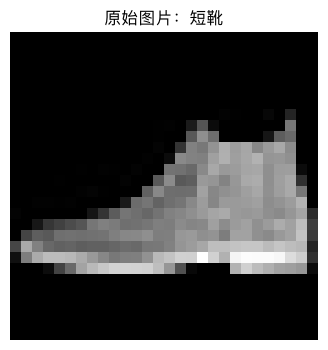

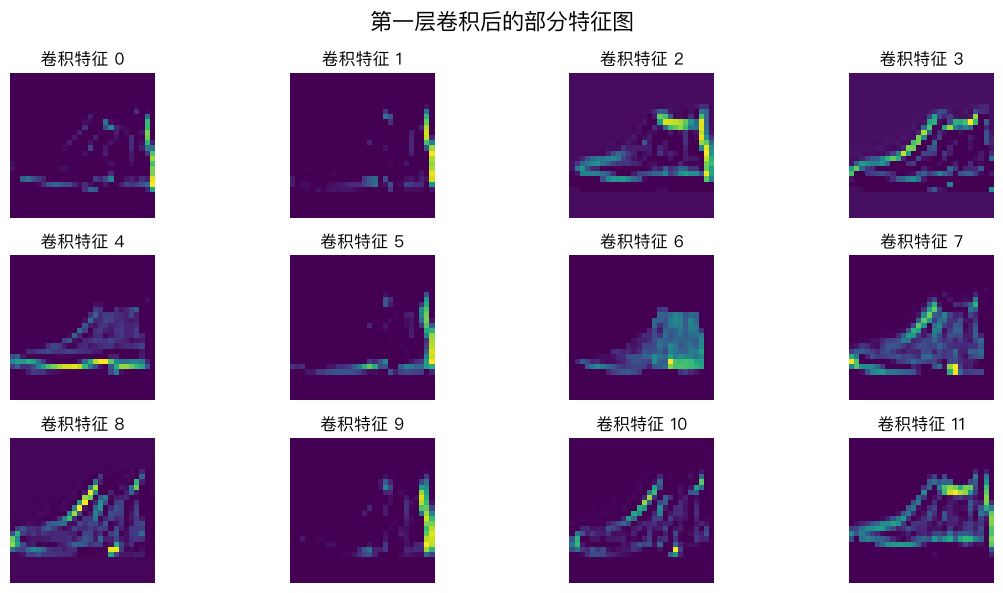

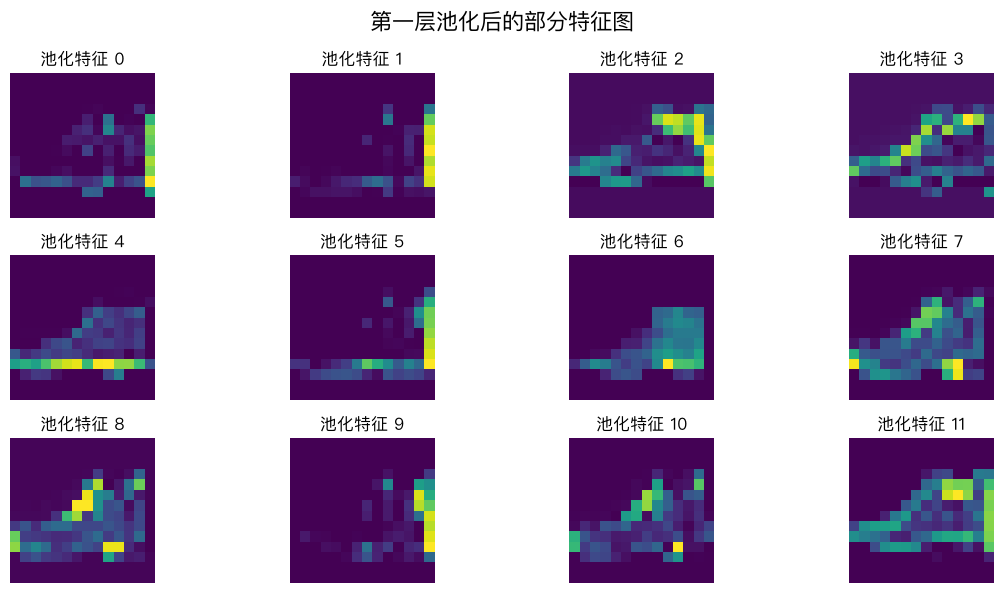

In [13]:
# ============================================================
# 第 10 步：可视化卷积特征图和池化特征图
# ============================================================

feature_image_index = 0
feature_image = x_test_cnn[feature_image_index:feature_image_index + 1]
feature_label = y_test[feature_image_index]

# 创建一个新模型：输入仍然是原始图片，输出改成中间层结果。
feature_model = keras.Model(
    inputs=model.inputs,
    outputs=[
        model.get_layer("conv_1_32_filters").output,
        model.get_layer("pool_1_2x2").output,
    ],
)

conv_features, pool_features = feature_model.predict(feature_image, verbose=0)

print("原始图片形状：", feature_image.shape)
print("第一层卷积特征图形状：", conv_features.shape)
print("第一层池化特征图形状：", pool_features.shape)

plt.figure(figsize=(4, 4))
plt.imshow(feature_image[0, :, :, 0], cmap="gray")
plt.title(f"原始图片：{class_names_cn[feature_label]}")
plt.axis("off")
plt.show()

num_features_to_show = 12

plt.figure(figsize=(12, 6))
for i in range(num_features_to_show):
    plt.subplot(3, 4, i + 1)
    plt.imshow(conv_features[0, :, :, i], cmap="viridis")
    plt.title(f"卷积特征 {i}")
    plt.axis("off")
plt.suptitle("第一层卷积后的部分特征图", fontsize=16)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
for i in range(num_features_to_show):
    plt.subplot(3, 4, i + 1)
    plt.imshow(pool_features[0, :, :, i], cmap="viridis")
    plt.title(f"池化特征 {i}")
    plt.axis("off")
plt.suptitle("第一层池化后的部分特征图", fontsize=16)
plt.tight_layout()
plt.show()

# 第 11 步：绘制训练过程曲线

训练结束后，重点观察两个指标：

- `loss`：损失值，越低通常越好
- `accuracy`：准确率，越高通常越好

同时比较训练集和验证集：

- 如果训练准确率和验证准确率都提高，说明模型在学习。
- 如果训练准确率继续提高，但验证准确率下降，可能出现过拟合。

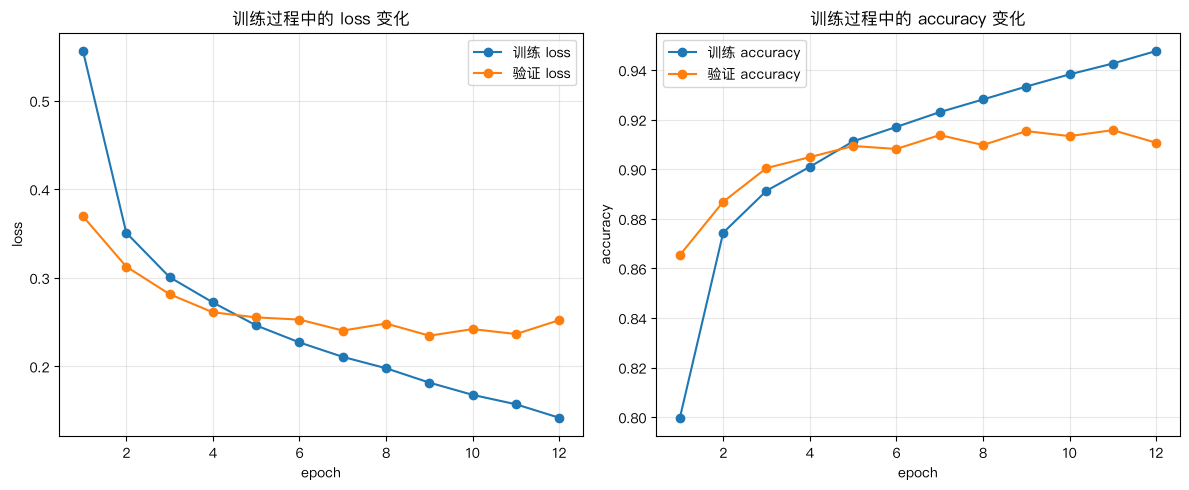

In [14]:
# ============================================================
# 第 11 步：绘制 loss 和 accuracy 曲线
# ============================================================

history_dict = history.history
epoch_numbers = range(1, len(history_dict["loss"]) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epoch_numbers, history_dict["loss"], marker="o", label="训练 loss")
plt.plot(epoch_numbers, history_dict["val_loss"], marker="o", label="验证 loss")
plt.title("训练过程中的 loss 变化")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epoch_numbers, history_dict["accuracy"], marker="o", label="训练 accuracy")
plt.plot(epoch_numbers, history_dict["val_accuracy"], marker="o", label="验证 accuracy")
plt.title("训练过程中的 accuracy 变化")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 第 12 步：在测试集上评估模型

测试集没有参与训练，也没有参与训练过程中的验证。

所以测试集结果更能反映模型面对新图片时的表现。

In [15]:
# ============================================================
# 第 12 步：测试集评估
# ============================================================

test_loss, test_accuracy = model.evaluate(x_test_cnn, y_test, verbose=0)

print("测试集 loss：", test_loss)
print("测试集 accuracy：", test_accuracy)
print(f"测试集准确率约为：{test_accuracy * 100:.2f}%")

测试集 loss： 0.26552698016166687
测试集 accuracy： 0.9103999733924866
测试集准确率约为：91.04%


# 第 13 步：观察单张图片的预测过程

模型最后输出 10 个概率。

概率最大的类别，就是模型最终预测的类别。

真实标签编号： 9
真实类别： 短靴
预测标签编号： 9
预测类别： 短靴
预测是否正确： True


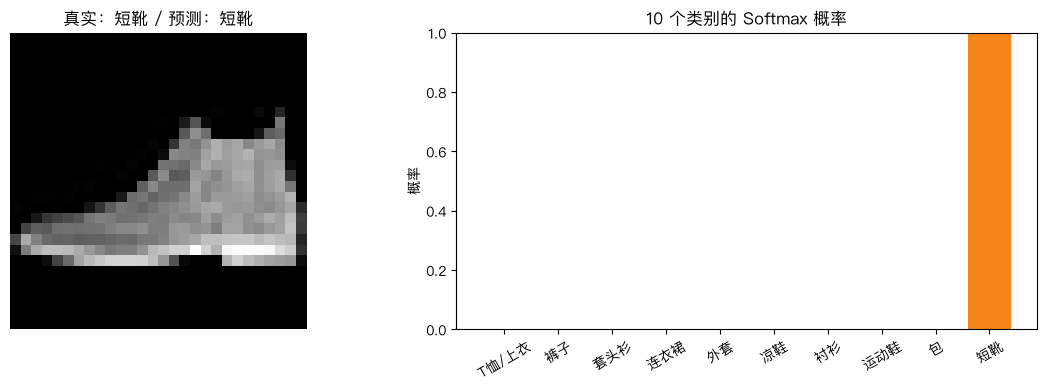

0 T恤/上衣：0.0000
1 裤子：0.0000
2 套头衫：0.0000
3 连衣裙：0.0000
4 外套：0.0000
5 凉鞋：0.0000
6 衬衫：0.0000
7 运动鞋：0.0000
8 包：0.0000
9 短靴：1.0000


In [16]:
# ============================================================
# 第 13 步：单张图片预测
# ============================================================

test_index = 0
single_image = x_test_cnn[test_index]
single_label = y_test[test_index]
single_image_batch = np.expand_dims(single_image, axis=0)

probabilities = model.predict(single_image_batch, verbose=0)[0]
predicted_label = np.argmax(probabilities)

print("真实标签编号：", single_label)
print("真实类别：", class_names_cn[single_label])
print("预测标签编号：", predicted_label)
print("预测类别：", class_names_cn[predicted_label])
print("预测是否正确：", predicted_label == single_label)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(single_image[:, :, 0], cmap="gray")
plt.title(f"真实：{class_names_cn[single_label]} / 预测：{class_names_cn[predicted_label]}")
plt.axis("off")

plt.subplot(1, 2, 2)
bar_colors = ["#F58518" if i == predicted_label else "#4C78A8" for i in range(10)]
plt.bar(class_names_cn, probabilities, color=bar_colors)
plt.title("10 个类别的 Softmax 概率")
plt.ylabel("概率")
plt.ylim(0, 1)
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

for label_id, probability in enumerate(probabilities):
    print(f"{label_id} {class_names_cn[label_id]}：{probability:.4f}")

# 第 14 步：批量展示预测结果

下面展示测试集中前 30 张图片的预测结果。

标题含义：

```text
真：真实类别
预：预测类别
```

颜色含义：

- 绿色：预测正确
- 红色：预测错误

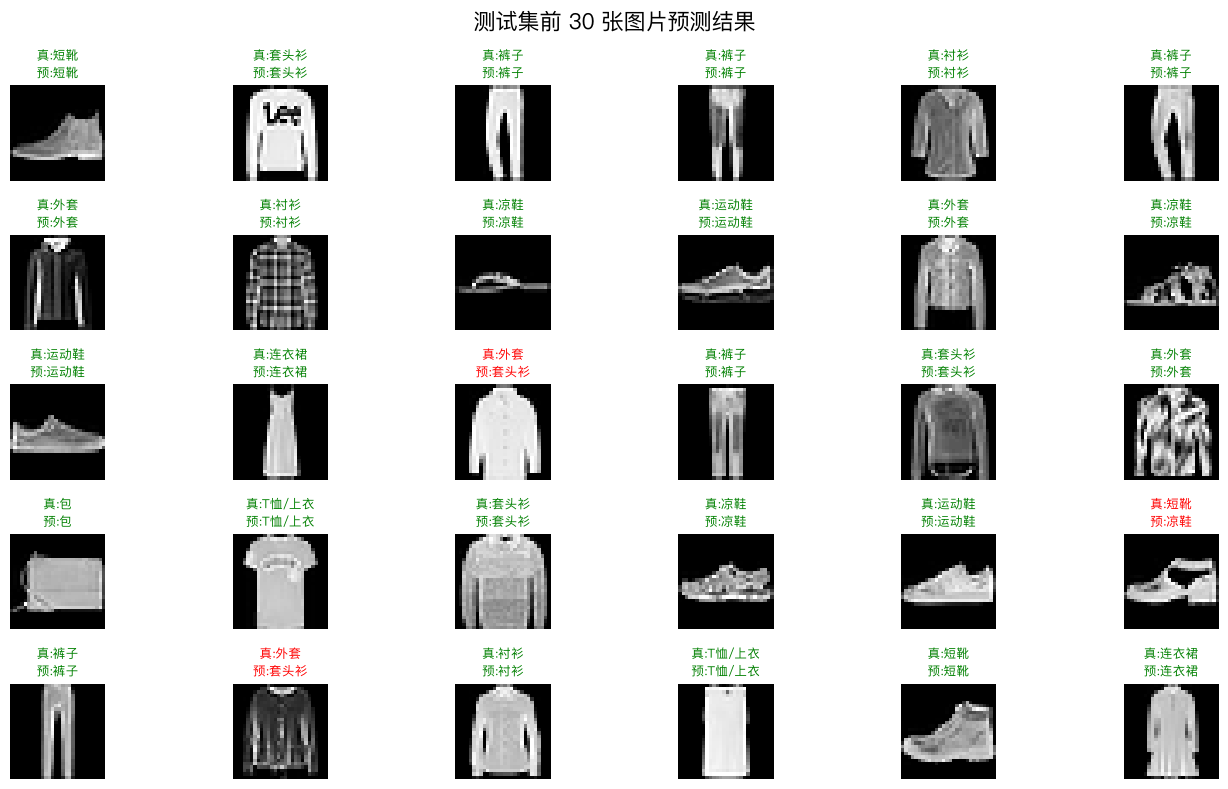

In [17]:
# ============================================================
# 第 14 步：批量展示测试集预测结果
# ============================================================

num_show = 30
predictions = model.predict(x_test_cnn[:num_show], verbose=0)
predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(14, 8))
for i in range(num_show):
    true_label = y_test[i]
    predicted_label = predicted_labels[i]
    correct = true_label == predicted_label
    title_color = "green" if correct else "red"

    plt.subplot(5, 6, i + 1)
    plt.imshow(x_test_cnn[i, :, :, 0], cmap="gray")
    plt.title(
        f"真:{class_names_cn[true_label]}\n预:{class_names_cn[predicted_label]}",
        color=title_color,
        fontsize=9,
    )
    plt.axis("off")

plt.suptitle("测试集前 30 张图片预测结果", fontsize=16)
plt.tight_layout()
plt.show()

# 第 15 步：混淆矩阵

混淆矩阵可以分析模型容易混淆哪些类别。

矩阵含义：

```text
行：真实类别
列：预测类别
```

混淆矩阵：
[[887   1  24  12   2   1  67   0   5   1]
 [  0 981   1  14   1   0   1   0   2   0]
 [ 21   0 919  10  16   0  34   0   0   0]
 [  8   2  14 945  13   0  16   0   2   0]
 [  1   0 160  34 734   0  69   0   2   0]
 [  1   0   0   0   0 986   0  11   0   2]
 [100   2  92  29  38   0 732   0   7   0]
 [  0   0   0   0   0   8   0 972   0  20]
 [  3   1   1   4   1   2   1   5 982   0]
 [  0   0   0   0   0   4   1  29   0 966]]


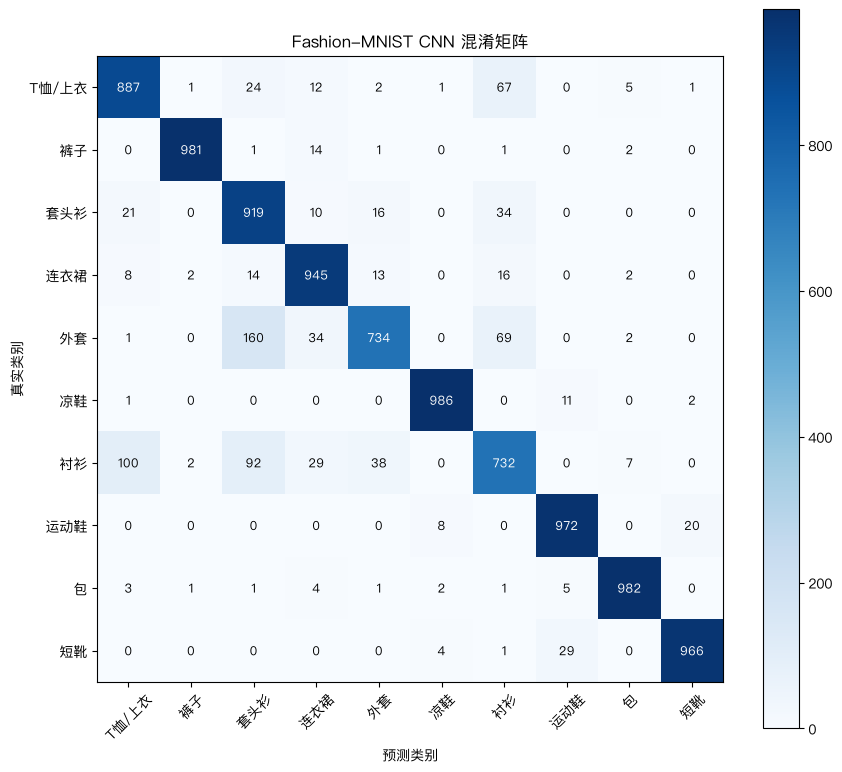

In [18]:
# ============================================================
# 第 15 步：计算并展示混淆矩阵
# ============================================================

all_predictions = model.predict(x_test_cnn, verbose=0)
all_predicted_labels = np.argmax(all_predictions, axis=1)

confusion_matrix = tf.math.confusion_matrix(
    labels=y_test,
    predictions=all_predicted_labels,
    num_classes=10,
).numpy()

print("混淆矩阵：")
print(confusion_matrix)

plt.figure(figsize=(9, 8))
plt.imshow(confusion_matrix, cmap="Blues")
plt.title("Fashion-MNIST CNN 混淆矩阵")
plt.xlabel("预测类别")
plt.ylabel("真实类别")
plt.xticks(range(10), class_names_cn, rotation=45)
plt.yticks(range(10), class_names_cn)
plt.colorbar()

for row in range(10):
    for col in range(10):
        value = confusion_matrix[row, col]
        text_color = "white" if value > confusion_matrix.max() * 0.5 else "black"
        plt.text(col, row, str(value), ha="center", va="center", color=text_color, fontsize=9)

plt.tight_layout()
plt.show()

# 第 16 步：找出最容易混淆的类别

混淆矩阵中：

- 对角线表示预测正确的数量
- 非对角线表示预测错误的数量

下面找出非对角线中数量最多的几个错误组合。

In [19]:
# ============================================================
# 第 16 步：分析最常见的错误组合
# ============================================================

cm_without_diagonal = confusion_matrix.copy()
np.fill_diagonal(cm_without_diagonal, 0)

flat_indices = np.argsort(cm_without_diagonal.ravel())[::-1]
top_k = 8
shown = 0

print(f"最常见的 {top_k} 类错误：")
for flat_index in flat_indices:
    true_label, predicted_label = np.unravel_index(flat_index, cm_without_diagonal.shape)
    count = cm_without_diagonal[true_label, predicted_label]

    if count == 0:
        break

    print(
        f"真实是 {class_names_cn[true_label]}，"
        f"被预测成 {class_names_cn[predicted_label]}：{count} 张"
    )

    shown += 1
    if shown >= top_k:
        break

最常见的 8 类错误：
真实是 外套，被预测成 套头衫：160 张
真实是 衬衫，被预测成 T恤/上衣：100 张
真实是 衬衫，被预测成 套头衫：92 张
真实是 外套，被预测成 衬衫：69 张
真实是 T恤/上衣，被预测成 衬衫：67 张
真实是 衬衫，被预测成 外套：38 张
真实是 套头衫，被预测成 衬衫：34 张
真实是 外套，被预测成 连衣裙：34 张


# 第 17 步：展示预测错误的图片

只看数字指标还不够。直接观察错误图片，可以帮助理解模型为什么会犯错。

常见原因包括：

1. 图片本身轮廓模糊。
2. 类别之间外形相似。
3. 服饰姿态、宽窄、边缘形状差异较大。
4. 28×28 分辨率较低，细节有限。

测试集中一共有 896 张预测错误。
测试集总数：10000
错误率约为：8.96%


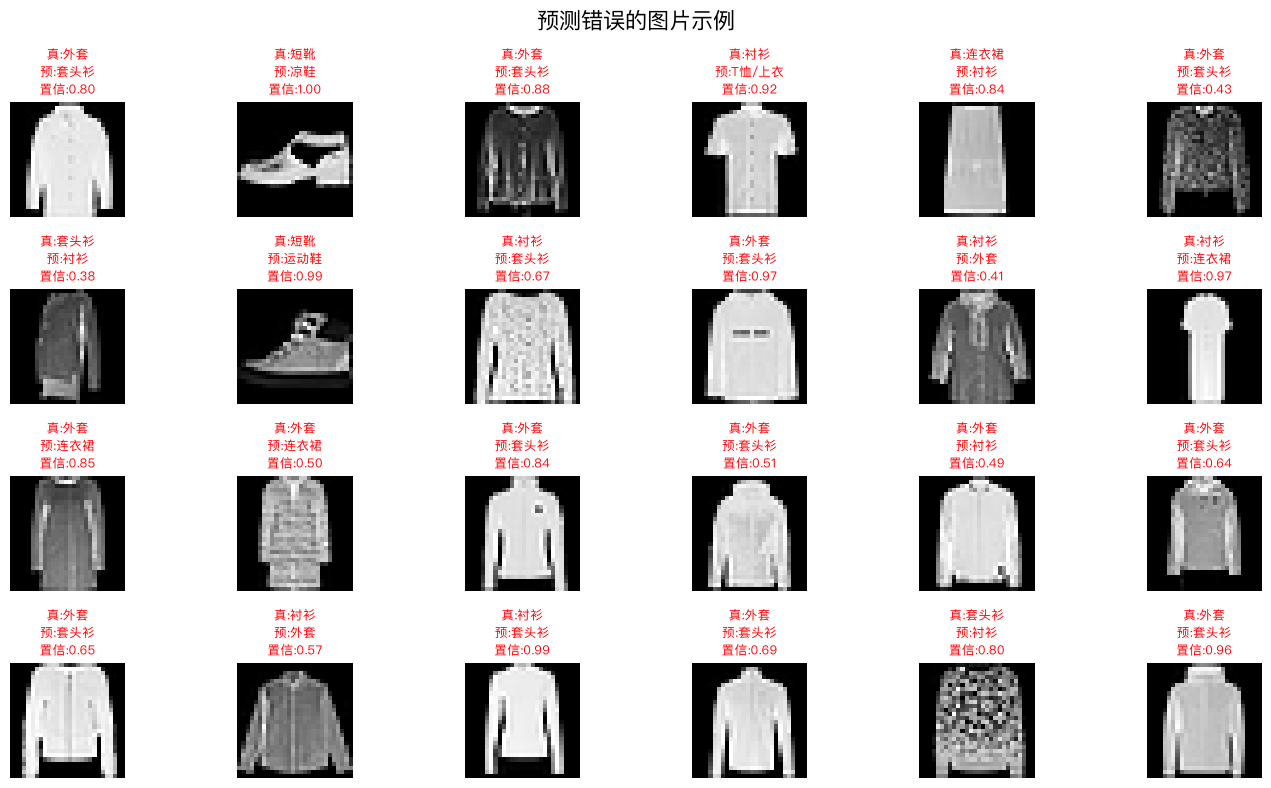

In [20]:
# ============================================================
# 第 17 步：展示模型预测错误的图片
# ============================================================

wrong_indices = np.where(all_predicted_labels != y_test)[0]

print(f"测试集中一共有 {len(wrong_indices)} 张预测错误。")
print(f"测试集总数：{len(y_test)}")
print(f"错误率约为：{len(wrong_indices) / len(y_test) * 100:.2f}%")

num_wrong_show = min(24, len(wrong_indices))
wrong_show_indices = wrong_indices[:num_wrong_show]

plt.figure(figsize=(14, 8))
for plot_position, image_index in enumerate(wrong_show_indices, start=1):
    true_label = y_test[image_index]
    predicted_label = all_predicted_labels[image_index]
    confidence = all_predictions[image_index, predicted_label]

    plt.subplot(4, 6, plot_position)
    plt.imshow(x_test_cnn[image_index, :, :, 0], cmap="gray")
    plt.title(
        f"真:{class_names_cn[true_label]}\n预:{class_names_cn[predicted_label]}\n置信:{confidence:.2f}",
        color="red",
        fontsize=9,
    )
    plt.axis("off")

plt.suptitle("预测错误的图片示例", fontsize=16)
plt.tight_layout()
plt.show()

# 第 18 步：保存模型

训练完成后，可以把模型保存下来。之后如果继续使用这个模型，不需要重新训练，直接加载即可。

Keras 推荐保存为 `.keras` 格式。

In [21]:
# ============================================================
# 第 18 步：保存模型
# ============================================================

model_save_path = "fashion_mnist_cnn_model.keras"
model.save(model_save_path)

print("模型已保存到：", model_save_path)

模型已保存到： fashion_mnist_cnn_model.keras


# 第 19 步：重新加载模型并验证

保存模型之后，可以用 `keras.models.load_model()` 重新加载。

这一步用于确认保存文件可以正常使用。

In [22]:
# ============================================================
# 第 19 步：重新加载模型并验证
# ============================================================

loaded_model = keras.models.load_model(model_save_path)
loaded_loss, loaded_accuracy = loaded_model.evaluate(x_test_cnn, y_test, verbose=0)

print("重新加载后的测试集 loss：", loaded_loss)
print("重新加载后的测试集 accuracy：", loaded_accuracy)

loaded_prediction = loaded_model.predict(np.expand_dims(x_test_cnn[0], axis=0), verbose=0)[0]
loaded_predicted_label = np.argmax(loaded_prediction)

print("第 0 张测试图片真实类别：", class_names_cn[y_test[0]])
print("重新加载模型后的预测类别：", class_names_cn[loaded_predicted_label])

重新加载后的测试集 loss： 0.26552698016166687
重新加载后的测试集 accuracy： 0.9103999733924866
第 0 张测试图片真实类别： 短靴
重新加载模型后的预测类别： 短靴


# 第 20 步：总结

通过这个案例，已经完成了一个完整的 CNN 图像分类任务。

核心流程如下：

1. Fashion-MNIST 图片是 28×28 灰度图。
2. CNN 输入需要写成 `28×28×1`，最后的 `1` 表示灰度通道。
3. 卷积层使用卷积核扫描图片，提取局部特征。
4. 池化层缩小特征图，保留更明显的局部特征。
5. CNN 不会一开始就把图片 Flatten，而是先保留空间结构进行特征提取。
6. 卷积和池化之后，再通过 Flatten 和 Dense 层完成分类。
7. Softmax 输出 10 个类别的概率。
8. 混淆矩阵和错误图片可以帮助分析模型容易错在哪里。

最核心的一句话：

> CNN 更适合图像任务，是因为它先从图片的局部区域中提取特征，再根据这些特征进行分类。